In [2]:
import pandas as pd
from datasets import load_dataset

In [3]:
dataset = load_dataset(
    "bitext/Bitext-customer-support-llm-chatbot-training-dataset",
    split = "train"
)

In [4]:
dataset

Dataset({
    features: ['flags', 'instruction', 'category', 'intent', 'response'],
    num_rows: 26872
})

In [5]:
df = dataset.to_pandas()
df.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [6]:
df.to_csv(
    "../data/raw/bitext_customer_support.csv",
    index = False
)

In [7]:
df.shape

(26872, 5)

In [8]:
df.columns

Index(['flags', 'instruction', 'category', 'intent', 'response'], dtype='str')

In [9]:
df.dtypes

flags          str
instruction    str
category       str
intent         str
response       str
dtype: object

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   flags        26872 non-null  str  
 1   instruction  26872 non-null  str  
 2   category     26872 non-null  str  
 3   intent       26872 non-null  str  
 4   response     26872 non-null  str  
dtypes: str(5)
memory usage: 19.1 MB


In [11]:
df.sample(10)

,flags,instruction,category,intent,response
17017,BK,subscription to your company newsletter,SUBSCRIPTION,newsletter_subscription,Thank you for expressing your interest in subs...
3139,BCLMP,"I would like to see the termination penalties,...",CANCEL,check_cancellation_fee,I'll make it happen! I'm here to assist you in...
11946,BLM,I have got to check what methods for delivery ...,DELIVERY,delivery_options,I'll make it happen! Let's dive into the realm...
12751,BLM,I don't know how to check what shipment method...,DELIVERY,delivery_options,No worries at all! I'm here to assist you in d...
11601,BLM,problems with gold account deletions,ACCOUNT,delete_account,Thank you for bringing up the issues you are f...
1325,BILQZ,how do ii modify order {{Order Number}},ORDER,change_order,We appreciate your inquiry to us with your req...
15481,BLM,I am calling to download my invoices from {{Pe...,INVOICE,get_invoice,I'll make it happen! I completely understand y...
4224,BL,I want assistance to give a quick look at the ...,INVOICE,check_invoice,I get it your need for a quick glance at the i...
21030,BL,I need assistance to inform of a registration ...,ACCOUNT,registration_problems,Thank you for contacting to us regarding a reg...
7543,BL,help me to lodge a customer claim,FEEDBACK,complaint,I'm sorry to hear that you're facing a situati...


In [12]:
df.isnull().sum()

flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["instruction"].duplicated().sum()

np.int64(2237)

In [15]:
df["category"].value_counts()

category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64

In [16]:
df["category"].nunique()

11

In [17]:
df["intent"].value_counts()

intent
check_invoice               1000
complaint                   1000
contact_customer_service    1000
edit_account                1000
switch_account              1000
check_payment_methods        999
contact_human_agent          999
delivery_period              999
get_invoice                  999
newsletter_subscription      999
payment_issue                999
registration_problems        999
cancel_order                 998
place_order                  998
track_refund                 998
change_order                 997
check_refund_policy          997
create_account               997
get_refund                   997
review                       997
set_up_shipping_address      997
delete_account               995
delivery_options             995
recover_password             995
track_order                  995
change_shipping_address      973
check_cancellation_fee       950
Name: count, dtype: int64

In [18]:
df["intent"].nunique()

27

In [19]:
sorted(df["intent"].unique())

['cancel_order',
 'change_order',
 'change_shipping_address',
 'check_cancellation_fee',
 'check_invoice',
 'check_payment_methods',
 'check_refund_policy',
 'complaint',
 'contact_customer_service',
 'contact_human_agent',
 'create_account',
 'delete_account',
 'delivery_options',
 'delivery_period',
 'edit_account',
 'get_invoice',
 'get_refund',
 'newsletter_subscription',
 'payment_issue',
 'place_order',
 'recover_password',
 'registration_problems',
 'review',
 'set_up_shipping_address',
 'switch_account',
 'track_order',
 'track_refund']

In [20]:
summary = pd.DataFrame({
    "Metric": [
        "Number of Rows",
        "Number of Columns",
        "Missing Values",
        "Duplicate Rows",
        "Unique Categories",
        "Unique Intents"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df["category"].nunique(),
        df["intent"].nunique()
    ]
})

summary

,Metric,Value
0,Number of Rows,26872
1,Number of Columns,5
2,Missing Values,0
3,Duplicate Rows,0
4,Unique Categories,11
5,Unique Intents,27


In [21]:
category_counts = df["category"].value_counts()

category_counts

category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64

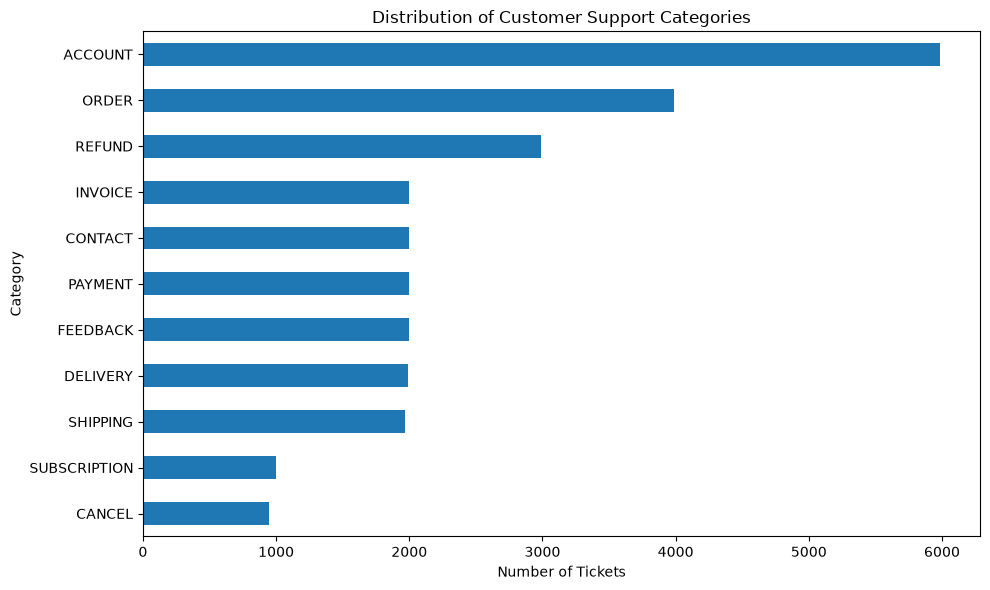

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

category_counts.sort_values().plot(kind="barh")

plt.title("Distribution of Customer Support Categories")
plt.xlabel("Number of Tickets")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [23]:
category_percentage = (
    df["category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

category_percentage

category
ACCOUNT         22.28
ORDER           14.84
REFUND          11.13
INVOICE          7.44
CONTACT          7.44
PAYMENT          7.44
FEEDBACK         7.43
DELIVERY         7.42
SHIPPING         7.33
SUBSCRIPTION     3.72
CANCEL           3.54
Name: proportion, dtype: float64

In [24]:
category_summary = pd.DataFrame({
    "Count": df["category"].value_counts(),
    "Percentage": df["category"].value_counts(normalize=True).mul(100).round(2)
})

category_summary

,Count,Percentage
category,,
ACCOUNT,5986,22.28
ORDER,3988,14.84
REFUND,2992,11.13
INVOICE,1999,7.44
CONTACT,1999,7.44
PAYMENT,1998,7.44
FEEDBACK,1997,7.43
DELIVERY,1994,7.42
SHIPPING,1970,7.33


In [25]:
intent_counts = df["intent"].value_counts()

intent_counts

intent
check_invoice               1000
complaint                   1000
contact_customer_service    1000
edit_account                1000
switch_account              1000
check_payment_methods        999
contact_human_agent          999
delivery_period              999
get_invoice                  999
newsletter_subscription      999
payment_issue                999
registration_problems        999
cancel_order                 998
place_order                  998
track_refund                 998
change_order                 997
check_refund_policy          997
create_account               997
get_refund                   997
review                       997
set_up_shipping_address      997
delete_account               995
delivery_options             995
recover_password             995
track_order                  995
change_shipping_address      973
check_cancellation_fee       950
Name: count, dtype: int64

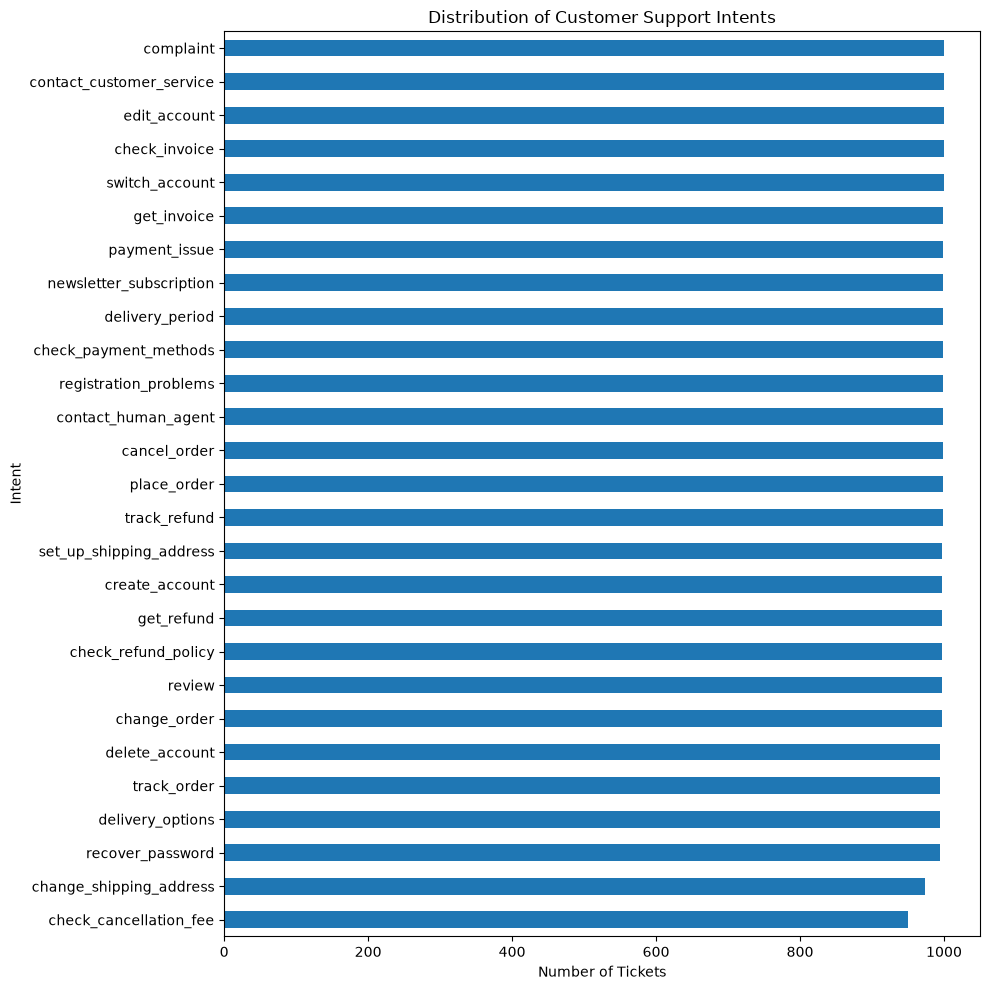

In [26]:
plt.figure(figsize=(10, 10))

intent_counts.sort_values().plot(kind="barh")

plt.title("Distribution of Customer Support Intents")
plt.xlabel("Number of Tickets")
plt.ylabel("Intent")

plt.tight_layout()
plt.show()

In [27]:
category_intent_table = pd.crosstab(
    df["category"],
    df["intent"]
)

category_intent_table

intent,cancel_order,change_order,change_shipping_address,check_cancellation_fee,check_invoice,check_payment_methods,check_refund_policy,complaint,contact_customer_service,contact_human_agent,...,newsletter_subscription,payment_issue,place_order,recover_password,registration_problems,review,set_up_shipping_address,switch_account,track_order,track_refund
category,,,,,,,,,,,,,,,,,,,,,
ACCOUNT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,995,999,0,0,1000,0,0
CANCEL,0,0,0,950,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CONTACT,0,0,0,0,0,0,0,0,1000,999,...,0,0,0,0,0,0,0,0,0,0
DELIVERY,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
FEEDBACK,0,0,0,0,0,0,0,1000,0,0,...,0,0,0,0,0,997,0,0,0,0
INVOICE,0,0,0,0,1000,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ORDER,998,997,0,0,0,0,0,0,0,0,...,0,0,998,0,0,0,0,0,995,0
PAYMENT,0,0,0,0,0,999,0,0,0,0,...,0,999,0,0,0,0,0,0,0,0
REFUND,0,0,0,0,0,0,997,0,0,0,...,0,0,0,0,0,0,0,0,0,998


In [28]:
category_intent_pairs = (
    df.groupby(["category", "intent"])
    .size()
    .reset_index(name="count")
    .sort_values(["category", "count"], ascending=[True, False])
)

category_intent_pairs

,category,intent,count
2,ACCOUNT,edit_account,1000
5,ACCOUNT,switch_account,1000
4,ACCOUNT,registration_problems,999
0,ACCOUNT,create_account,997
1,ACCOUNT,delete_account,995
3,ACCOUNT,recover_password,995
6,CANCEL,check_cancellation_fee,950
7,CONTACT,contact_customer_service,1000
8,CONTACT,contact_human_agent,999
10,DELIVERY,delivery_period,999


In [29]:
intent_category_check = (
    df.groupby("intent")["category"]
    .nunique()
    .sort_values(ascending=False)
)

intent_category_check

intent
cancel_order                1
change_order                1
change_shipping_address     1
check_cancellation_fee      1
check_invoice               1
check_payment_methods       1
check_refund_policy         1
complaint                   1
contact_customer_service    1
contact_human_agent         1
create_account              1
delete_account              1
delivery_options            1
delivery_period             1
edit_account                1
get_invoice                 1
get_refund                  1
newsletter_subscription     1
payment_issue               1
place_order                 1
recover_password            1
registration_problems       1
review                      1
set_up_shipping_address     1
switch_account              1
track_order                 1
track_refund                1
Name: category, dtype: int64

In [30]:
intent_category_check[intent_category_check > 1]

Series([], Name: category, dtype: int64)

In [31]:
df["instruction_char_length"] = df["instruction"].astype(str).str.len()

In [32]:
df["instruction_word_count"] = (
    df["instruction"]
    .astype(str)
    .str.split()
    .str.len()
)

In [33]:
df[[
    "instruction_char_length",
    "instruction_word_count"
]].describe()

,instruction_char_length,instruction_word_count
count,26872.000000,26872.000000
mean,46.889513,8.690979
std,10.897578,2.605004
min,6.000000,1.000000
25%,40.000000,7.000000
50%,48.000000,9.000000
75%,55.000000,11.000000
max,92.000000,16.000000


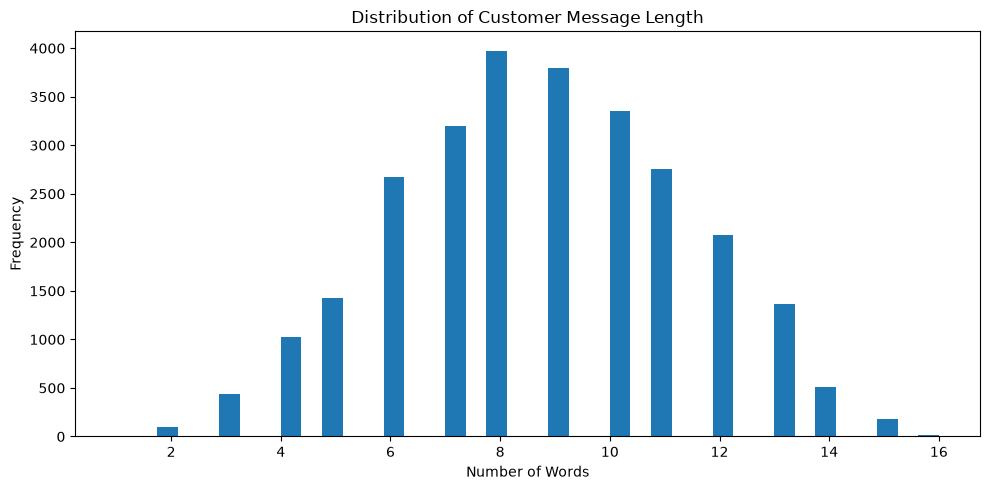

In [34]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["instruction_word_count"],
    bins=40
)

plt.title("Distribution of Customer Message Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [35]:
df["response_word_count"] = (
    df["response"]
    .astype(str)
    .str.split()
    .str.len()
)

In [36]:
df["response_word_count"].describe()

count    26872.000000
mean       104.789037
std         52.966204
min          9.000000
25%         72.000000
50%         90.000000
75%        124.000000
max        402.000000
Name: response_word_count, dtype: float64

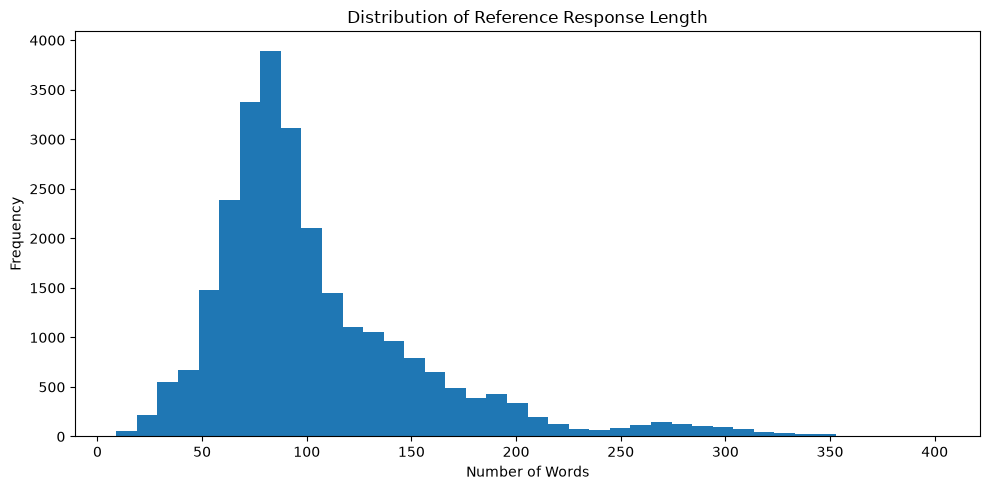

In [37]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["response_word_count"],
    bins=40
)

plt.title("Distribution of Reference Response Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [38]:
category_message_length = (
    df.groupby("category")["instruction_word_count"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
    .sort_values("mean", ascending=False)
)

category_message_length

,mean,median,min,max
category,,,,
DELIVERY,9.67,10.0,2,16
REFUND,9.48,10.0,2,16
FEEDBACK,9.17,9.0,1,15
INVOICE,9.14,9.0,2,15
CONTACT,8.82,9.0,1,15
PAYMENT,8.58,8.0,2,15
SUBSCRIPTION,8.36,8.0,3,15
ACCOUNT,8.28,8.0,1,16
SHIPPING,8.25,8.0,2,15


In [39]:
df["flags"].value_counts().head(20)

flags
BL       5212
BLQ      2467
BIL      2138
BLM      1297
BILQ     1057
BLQZ      970
BLZ       902
BKL       862
BLMQ      600
BEL       533
BILM      521
BCL       484
BCIL      427
BILQZ     412
BILP      363
B         353
BK        352
BQ        340
BKLZ      322
BLW       309
Name: count, dtype: int64

In [40]:
df["flags"].nunique()

394

In [41]:
df[["flags", "instruction"]].sample(10)

,flags,instruction
1799,BL,help me switching an article of purchase {{Ord...
13405,BLZ,assistance seeing how soon can I exect my deli...
6821,BL,I want help seeing in which situations can I a...
15159,BLQ,i dont know what i need to do to get the bill ...
11596,BKLZ,delete standard acvount
1176,BLQ,i want assistance to swap something of purchas...
14399,BKL,correcting information on {{Account Category}}...
3525,BLMQ,i need help to see the cancellation charges
25887,BLQZ,I'm waiting for a reimbjrsement of {{Currency ...
20572,BELQ,I do not know what I need to do to retrieve my...


In [42]:
df["instruction"].duplicated().sum()

np.int64(2237)

In [43]:
duplicate_instructions = df[
    df.duplicated(subset=["instruction"], keep=False)
].sort_values("instruction")

duplicate_instructions[
    ["instruction", "category", "intent", "response"]
].head(20)

,instruction,category,intent,response
25320,ETA of order {{Order Number}},ORDER,track_order,It's great to hear from you! I can see that yo...
25447,ETA of order {{Order Number}},ORDER,track_order,We're all ears! I'm tuned into the idea that y...
25557,ETA of order {{Order Number}},ORDER,track_order,Thank you for your query! I understand that yo...
25605,ETA of order {{Order Number}},ORDER,track_order,Thank you for contacting us! I'm here to assis...
25864,ETA of order {{Order Number}},ORDER,track_order,Your input is valuable! I'm picking up that yo...
24880,ETA of purchase {{Order Number}},ORDER,track_order,Thank you for reaching out! I'm here to assist...
25846,ETA of purchase {{Order Number}},ORDER,track_order,Thank you for contacting! I certainly recogniz...
235,I am trying to cancel order {{Order Number}},ORDER,cancel_order,I've been informed that you're currently attem...
636,I am trying to cancel order {{Order Number}},ORDER,cancel_order,I've realized that you are trying to cancel yo...
418,I am trying to cancel purchaes {{Order Number}},ORDER,cancel_order,I hear you loud and clear that you're trying t...


In [44]:
duplicate_label_check = (
    df.groupby("instruction")
    .agg(
        category_count=("category", "nunique"),
        intent_count=("intent", "nunique")
    )
)

duplicate_label_check[
    (duplicate_label_check["category_count"] > 1) |
    (duplicate_label_check["intent_count"] > 1)
]

,category_count,intent_count
instruction,,


In [45]:
for category in df["category"].unique():
    print(f"\n{'=' * 60}")
    print(f"CATEGORY: {category}")
    print("=" * 60)

    samples = df[df["category"] == category].sample(
        min(3, len(df[df["category"] == category])),
        random_state=42
    )

    for _, row in samples.iterrows():
        print("\nCustomer:")
        print(row["instruction"])

        print("\nIntent:")
        print(row["intent"])

        print("\nReference Response:")
        print(row["response"])

        print("-" * 60)


CATEGORY: ORDER

Customer:
can you help me remove something from purchase {{Order Number}}?

Intent:
change_order

Reference Response:
We understand that you are looking for assistance in removing an item from your purchase with the order number {{Order Number}}. We apologize for any inconvenience caused. To better assist you, could you please provide us with the specific item you would like to remove? Once we have this information, we will promptly assist you in updating your purchase. Your satisfaction is our top priority, and we appreciate your patience and cooperation in resolving this matter.
------------------------------------------------------------

Customer:
i dont know how  to purchase several products

Intent:
place_order

Reference Response:
Happy to hear from you! I truly understand that you may be unfamiliar with the process of purchasing several products, but don't worry, I'm here to help. To get started, could you please let me know which specific products you're inte

In [46]:
print("DATASET SUMMARY")
print("-" * 50)

print(f"Total tickets: {len(df):,}")
print(f"Categories: {df['category'].nunique()}")
print(f"Intents: {df['intent'].nunique()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

print(
    f"Average customer message length: "
    f"{df['instruction_word_count'].mean():.2f} words"
)

print(
    f"Average response length: "
    f"{df['response_word_count'].mean():.2f} words"
)

print("\nLargest Category:")
print(df["category"].value_counts().idxmax())

print("\nSmallest Category:")
print(df["category"].value_counts().idxmin())

DATASET SUMMARY
--------------------------------------------------
Total tickets: 26,872
Categories: 11
Intents: 27
Missing values: 0
Duplicate rows: 0
Average customer message length: 8.69 words
Average response length: 104.79 words

Largest Category:
ACCOUNT

Smallest Category:
CANCEL
